## orflib Library Examples

In [1]:
import orflib as orf
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('ggplot')

print("orflib version: {0}".format(orf.version()))
print("pid: {0}".format(os.getpid()))

orflib version: 0.7.0-debug
pid: 8101


### Market Objects

In [2]:
#yccreate
ycname = "USD"
yc = orf.ycCreate(ycname = ycname, 
                  tmats = [1/12,   1/4,  1/2,   3/4,    1,     2,    3,    5], 
                  vals =  [0.01,  0.02, 0.03, 0.035, 0.040, 0.048, 0.053, 0.06],
                  valtype = 0)
print(f'Created yield curve: {yc}')

Created yield curve: USD


### Monte Carlo

In [3]:
# European Option

mcpars0 = {'URNGTYPE': 'MT19937', 'PATHGENTYPE': 'EULER'}
path = 512
prices = []
paths = []
std = []
while (path<=262144):
    euromc0 = orf.euroBSMC(payofftype = -1, strike = 120, timetoexp = 2.0, spot = 100,
                           discountcrv =  yc, divyield = 0, volatility = 0.6,
                           mcparams = mcpars0, npaths = path)
    prices.append(euromc0['Mean'])
    std.append(euromc0['StdErr'])
    paths.append(path)
    path*=2

mcpars0 = {'URNGTYPE': 'MT19937', 'PATHGENTYPE': 'EULER', 'CONTROLVARTYPE': 'ANTITHETIC'}
path = 512
prices_a = []
stds_a = []
while (path<=262144):
    euromc0 = orf.euroBSMC(payofftype = -1, strike = 120, timetoexp = 2.0, spot = 100,
                           discountcrv =  yc, divyield = 0, volatility = 0.6,
                           mcparams = mcpars0, npaths = path)
    prices_a.append(euromc0['Mean'])
    stds_a.append(euromc0['StdErr'])
    path*=2


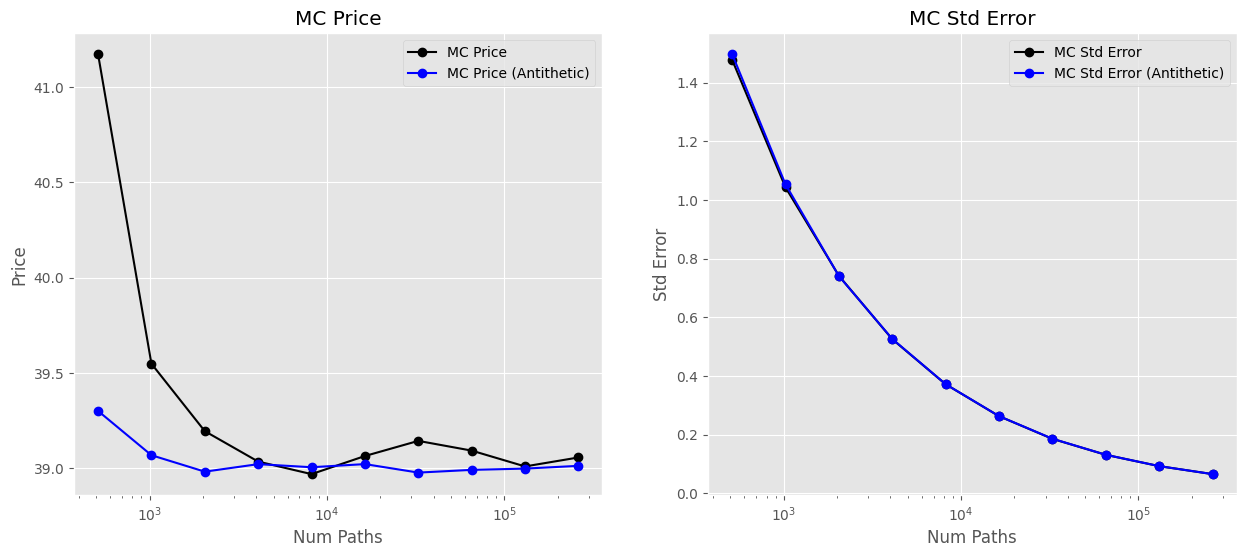

In [4]:
# plot prices and errors
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(paths, prices, color='black', marker='o', label='MC Price')
plt.plot(paths, prices_a, color='blue', marker='o', label='MC Price (Antithetic)')
plt.xscale('log')
plt.title("MC Price")
plt.xlabel('Num Paths')
plt.ylabel('Price')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(paths, std, color='black', marker='o', label='MC Std Error')
plt.plot(paths, stds_a, color='blue', marker='o', label='MC Std Error (Antithetic)')
plt.xscale('log')
plt.title("MC Std Error")
plt.xlabel('Num Paths')
plt.ylabel('Std Error')
plt.legend()
plt.show()

In [7]:
# Worst-of Digital Option Parameters
nassets = 3
spots = np.array([100.0, 100.0, 100.0])  # ATM strike = 100% of spot
strike = 1  # ATM for relative return
time_fix = 1.0  # T1 = 1 year
time_exp = 2.0  # T2 = 2 years
vol = 0.3  # 30% volatility for all assets
divs = np.zeros(nassets)  # 0% dividend yield
vols = np.full(nassets, vol)  # Same volatility for all assets

# Correlation matrix with ρ = 50%
rho = 0.5
corr = np.ones((nassets, nassets))
for i in range(nassets):
    for j in range(nassets):
        if i != j:
            corr[i,j] = rho

# MC parameters
mcpars = {'URNGTYPE': 'MT19937', 'PATHGENTYPE': 'EULER'}
npaths = 1000000

# Price call and put options
call = orf.worstofDigiBSMC(payofftype=1, strike=strike, timetofix=time_fix, timetoexp=time_exp,
                          spots=spots, discountcrv=yc, divyields=divs, volatilities=vols,
                          correlmat=corr, mcparams=mcpars, npaths=npaths)

put = orf.worstofDigiBSMC(payofftype=-1, strike=strike, timetofix=time_fix, timetoexp=time_exp,
                         spots=spots, discountcrv=yc, divyields=divs, volatilities=vols,
                         correlmat=corr, mcparams=mcpars, npaths=npaths)

# Calculate present value of $1 paid at expiration
r = orf.fwdRate(yc, 0, time_exp)
pv_1 = np.exp(-r * time_exp)

print(f"Digital Call Price: {call['Mean']:.6f} (±{call['StdErr']:.6f})")
print(f"Digital Put Price: {put['Mean']:.6f} (±{put['StdErr']:.6f})")
print(f"Sum of Call + Put: {(call['Mean'] + put['Mean']):.6f}")
print(f"PV of $1 at expiry: {pv_1:.6f}")
print(f"Difference: {abs(call['Mean'] + put['Mean'] - pv_1):.6f}")

Digital Call Price: 0.239498 (±0.000400)
Digital Put Price: 0.668966 (±0.000400)
Sum of Call + Put: 0.908464
PV of $1 at expiry: 0.908464
Difference: 0.000000


### Analysis of Results

For the worst-of digital options:
1. The ATM strike is set to K = 100% (1.0 when working with relative returns)
2. We price both call and put options with same parameters:
   - 3 assets with equal spot prices (100)
   - Equal volatilities (30%)
   - Equal pairwise correlations (50%)
   - Fixing time T₁ = 1 year
   - Expiry time T₂ = 2 years
   - Zero dividend yields

The sum of call and put prices should equal the present value of 1 paid at T₂ = 2 years, due to put-call parity for digital options. This is because:
- For any given path, exactly one of the options will pay 1 (either call or put)
- Therefore, the sum of payoffs is always 1 at expiration
- The present value of this 1 is calculated using the yield curve

In [8]:
# We run this for multiple strikes as well
strikes = [0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.1,1.2,1.3]
df = pd.DataFrame(columns=['Strike', 'Call', 'Put', 'Sum', 'PV of $1', 'Diff'])
for strike in strikes:
    # Price call and put options
    call = orf.worstofDigiBSMC(payofftype=1, strike=strike, timetofix=time_fix, timetoexp=time_exp,
                              spots=spots, discountcrv=yc, divyields=divs, volatilities=vols,
                              correlmat=corr, mcparams=mcpars, npaths=npaths)
    
    put = orf.worstofDigiBSMC(payofftype=-1, strike=strike, timetofix=time_fix, timetoexp=time_exp,
                             spots=spots, discountcrv=yc, divyields=divs, volatilities=vols,
                             correlmat=corr, mcparams=mcpars, npaths=npaths)
    
    # Calculate present value of $1 paid at expiration
    r = orf.fwdRate(yc, 0, time_exp)
    pv_1 = np.exp(-r * time_exp)
    
    # Create a new row of data
    new_row = pd.DataFrame({
        'Strike': [strike],
        'Call': [call['Mean']],
        'Put': [put['Mean']],
        'Sum': [call['Mean'] + put['Mean']],
        'PV of $1': [pv_1],
        'Diff': [abs(call['Mean'] + put['Mean'] - pv_1)]
    })
    if not df.empty:
        df = pd.concat([df, new_row], ignore_index=True)
    else:
        df = new_row

print(df.to_string(index=False, float_format=lambda x: '{:.6f}'.format(x)))

  Strike     Call      Put      Sum  PV of $1     Diff
0.300000 0.908395 0.000069 0.908464  0.908464 0.000000
0.400000 0.905784 0.002680 0.908464  0.908464 0.000000
0.500000 0.885498 0.022966 0.908464  0.908464 0.000000
0.600000 0.818839 0.089625 0.908464  0.908464 0.000000
0.700000 0.693044 0.215420 0.908464  0.908464 0.000000
0.800000 0.530548 0.377916 0.908464  0.908464 0.000000
0.900000 0.370469 0.537995 0.908464  0.908464 0.000000
1.000000 0.239498 0.668966 0.908464  0.908464 0.000000
1.100000 0.144614 0.763850 0.908464  0.908464 0.000000
1.200000 0.082889 0.825575 0.908464  0.908464 0.000000
1.300000 0.045801 0.862663 0.908464  0.908464 0.000000
